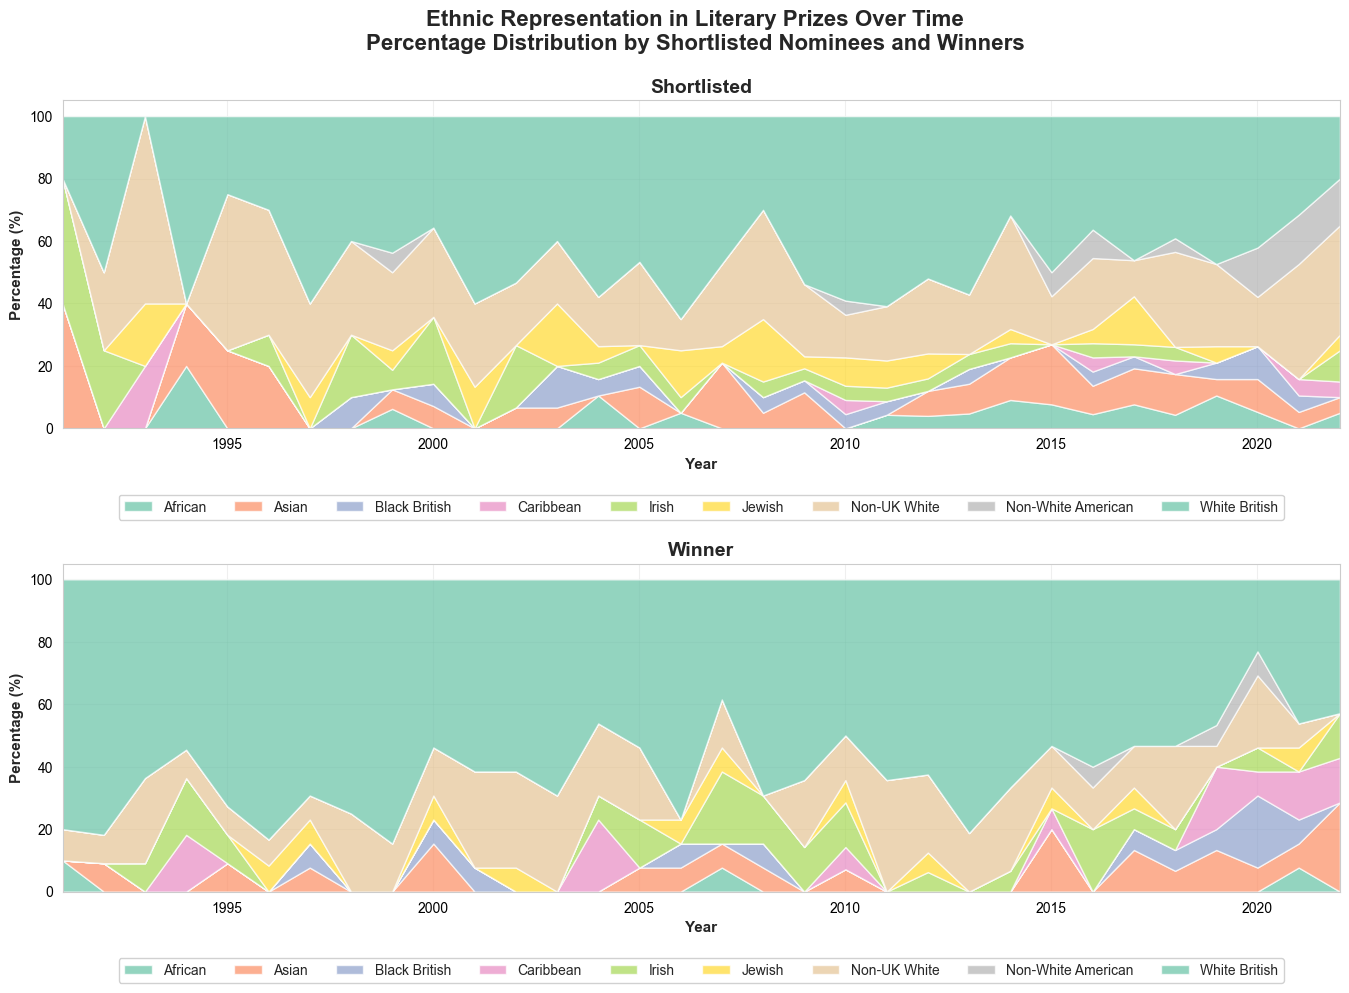

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
prizes = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-10-28/prizes.csv')

# Set my style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)


# Pepare data
ethnicity_time = prizes.dropna(subset=['ethnicity_macro', 'person_role', 'prize_year'])

# Calculate percentages
ethnicity_pct = (ethnicity_time.groupby(['prize_year', 'person_role', 'ethnicity_macro'])
                 .size()
                 .reset_index(name='count'))

ethnicity_pct['total'] = ethnicity_pct.groupby(['prize_year', 'person_role'])['count'].transform('sum')
ethnicity_pct['percentage'] = (ethnicity_pct['count'] / ethnicity_pct['total']) * 100

# Create percentage area plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

roles = ethnicity_pct['person_role'].unique()
colors = sns.color_palette("Set2", n_colors=len(ethnicity_pct['ethnicity_macro'].unique()))

for idx, role in enumerate(sorted(roles)):
    ax = axes[idx]
    
    # Filter data for role
    role_data = ethnicity_pct[ethnicity_pct['person_role'] == role]
    
    # Pivot for area plot
    pivot_data = role_data.pivot(index='prize_year', columns='ethnicity_macro', values='percentage').fillna(0)
    
    # Create stacked area plot
    ax.stackplot(pivot_data.index, 
                 [pivot_data[col] for col in pivot_data.columns],
                 labels=pivot_data.columns,
                 alpha=0.7,
                 colors=colors[:len(pivot_data.columns)])
    
    ax.set_title(f'{role}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year', fontsize=11, fontweight="bold")
    ax.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
    ax.legend(title='', loc='lower center',bbox_to_anchor =(.5, -.3), ncol=9, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1991, 2022)
    ax.tick_params(axis='both', labelsize=10, width=1.2, labelcolor='black')
    display_role = 'Shortlisted' if role.lower() == 'shortlisted' else 'Winner'
    ax.set_title(display_role, fontsize=14, fontweight='bold')

plt.suptitle('Ethnic Representation in Literary Prizes Over Time\nPercentage Distribution by Shortlisted Nominees and Winners', 
             fontsize=16, fontweight='bold', y=0.995)
plt.savefig('ethnic_representation_plot.pdf', bbox_inches='tight')
plt.savefig('ethnic_representation_plot.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


In [21]:
pivot_data

ethnicity_macro,African,Asian,Black British,Caribbean,Irish,Jewish,Non-UK White,Non-White American,White British
prize_year,,,,,,,,,
1991,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,0.000000,80.000000
1992,0.000000,9.090909,0.000000,0.000000,0.000000,0.000000,9.090909,0.000000,81.818182
1993,0.000000,0.000000,0.000000,0.000000,9.090909,0.000000,27.272727,0.000000,63.636364
1994,0.000000,0.000000,0.000000,18.181818,18.181818,0.000000,9.090909,0.000000,54.545455
1995,0.000000,9.090909,0.000000,0.000000,9.090909,0.000000,9.090909,0.000000,72.727273
1996,0.000000,0.000000,0.000000,0.000000,0.000000,8.333333,8.333333,0.000000,83.333333
1997,0.000000,7.692308,7.692308,0.000000,0.000000,7.692308,7.692308,0.000000,69.230769
1998,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,75.000000
1999,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.384615,0.000000,84.615385


In [24]:
role_data

,prize_year,person_role,ethnicity_macro,count,total,percentage
3,1991,winner,African,1,10,10.000000
4,1991,winner,Non-UK White,1,10,10.000000
5,1991,winner,White British,8,10,80.000000
9,1992,winner,Asian,1,11,9.090909
10,1992,winner,Non-UK White,1,11,9.090909
...,...,...,...,...,...,...
282,2021,winner,White British,6,13,46.153846
291,2022,winner,Asian,2,7,28.571429
292,2022,winner,Caribbean,1,7,14.285714
293,2022,winner,Irish,1,7,14.285714
